# Klasifikasi Batik - Ekstraksi Fitur MobileNetV2 Saja

Notebook ini merupakan bagian dari *Ablation Study* untuk mengevaluasi performa model klasifikasi jika HANYA menggunakan fitur visual dari Deep Learning (MobileNetV2) tanpa fitur tekstur statistik.


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import seaborn as sns


In [2]:
TRAIN_DIR = 'dataset/train'
TEST_DIR = 'dataset/test'
IMG_SIZE = (224, 224)

print("Loading MobileNetV2...")
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.trainable = False

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    return final_img

def apply_zero_padding(img, target_size=(224, 224)):
    old_size = img.shape[:2]
    ratio = min(target_size[0]/old_size[0], target_size[1]/old_size[1])
    new_size = tuple([int(x*ratio) for x in old_size])
    
    img_resized = cv2.resize(img, (new_size[1], new_size[0]))
    
    delta_w = target_size[1] - new_size[1]
    delta_h = target_size[0] - new_size[0]
    top, bottom = delta_h//2, delta_h-(delta_h//2)
    left, right = delta_w//2, delta_w-(delta_w//2)
    
    color = [0, 0, 0]
    new_img = cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return new_img

def extract_cnn_features(img, model):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_padded = apply_zero_padding(img_rgb, target_size=IMG_SIZE)
    
    img_array = img_to_array(img_padded)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    features = model.predict(img_array, verbose=0)
    return features.flatten()


Loading MobileNetV2...




In [3]:
def process_dataset(directory, cnn_model, augment_rotation=False):
    features = []
    labels = []
    classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    
    for class_name in tqdm(classes, desc=f"Processing {directory}"):
        class_dir = os.path.join(directory, class_name)
        for img_name in os.listdir(class_dir):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            img_clahe = apply_clahe(img)
            rotations = [None]
            if augment_rotation:
                rotations.extend([cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE])
                
            for rot in rotations:
                try:
                    img_processed = cv2.rotate(img_clahe, rot) if rot is not None else img_clahe
                    cnn_feats = extract_cnn_features(img_processed, cnn_model)
                    features.append(cnn_feats)
                    labels.append(class_name)
                except Exception as e:
                    pass
    return np.array(features), np.array(labels)

X_train, y_train_raw = process_dataset(TRAIN_DIR, base_model, augment_rotation=True)
X_test, y_test_raw = process_dataset(TEST_DIR, base_model, augment_rotation=False)


Processing dataset/test: 100%|██████████| 20/20 [01:18<00:00,  3.92s/it]


In [4]:
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Dimensi fitur CNN sebelum PCA: {X_train_scaled.shape[1]}")
print(f"Dimensi fitur CNN setelah PCA: {X_train_pca.shape[1]}")


Dimensi fitur CNN sebelum PCA: 1280
Dimensi fitur CNN setelah PCA: 674


## Evaluasi Multi-Model (Ablation MobileNetV2)

In [5]:
models = {
    "SVM": {
        "model": SVC(C=10, kernel='rbf', probability=True, random_state=42),
        "param_info": "C=10, kernel='rbf'"
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(n_neighbors=3, weights='distance'),
        "param_info": "n_neighbors=3, weights='distance'"
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42),
        "param_info": "n_estimators=100, max_depth=20"
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(max_depth=None, random_state=42),
        "param_info": "max_depth=None"
    },
    "Dense Neural Network (MLP)": {
        "model": MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42),
        "param_info": "hidden_layers=(256, 128), max_iter=500"
    }
}

results = {}

for name, info in models.items():
    print(f"Melatih model {name} (MobileNetV2 Saja)...")
    model = info["model"]
    
    start_train = time.time()
    model.fit(X_train_pca, y_train)
    end_train = time.time()
    
    start_pred = time.time()
    y_pred = model.predict(X_test_pca)
    end_pred = time.time()
    
    acc = accuracy_score(y_test, y_pred)
    train_time = end_train - start_train
    pred_time = end_pred - start_pred
    
    results[name] = {
        'accuracy': acc,
        'predictions': y_pred,
        'train_time': train_time,
        'pred_time': pred_time,
        'param_info': info["param_info"]
    }
    
    print(f"-> Waktu Latih: {train_time:.4f} detik | Waktu Prediksi: {pred_time:.4f} detik")
    print(f"-> Selesai! Akurasi: {acc * 100:.2f}%\n")


Melatih model SVM (MobileNetV2 Saja)...
-> Waktu Latih: 29.7160 detik | Waktu Prediksi: 1.2452 detik
-> Selesai! Akurasi: 95.94%

Melatih model K-Nearest Neighbors (MobileNetV2 Saja)...
-> Waktu Latih: 0.0371 detik | Waktu Prediksi: 2.7251 detik
-> Selesai! Akurasi: 93.75%

Melatih model Random Forest (MobileNetV2 Saja)...
-> Waktu Latih: 29.7509 detik | Waktu Prediksi: 0.0113 detik
-> Selesai! Akurasi: 91.56%

Melatih model Decision Tree (MobileNetV2 Saja)...
-> Waktu Latih: 4.7527 detik | Waktu Prediksi: 0.0000 detik
-> Selesai! Akurasi: 62.50%

Melatih model Dense Neural Network (MLP) (MobileNetV2 Saja)...
-> Waktu Latih: 6.0834 detik | Waktu Prediksi: 0.0020 detik
-> Selesai! Akurasi: 95.31%



TABEL PERBANDINGAN MODEL KLASIFIKASI BATIK (MOBILENETV2 SAJA)


,Model,Akurasi (%),Waktu Latih (detik),Waktu Prediksi (detik),Parameter Terbaik
0,SVM,95.94,29.7160,1.2452,"C=10, kernel='rbf'"
1,K-Nearest Neighbors,93.75,0.0371,2.7251,"n_neighbors=3, weights='distance'"
2,Random Forest,91.56,29.7509,0.0113,"n_estimators=100, max_depth=20"
3,Decision Tree,62.50,4.7527,0.0000,max_depth=None
4,Dense Neural Network (MLP),95.31,6.0834,0.0020,"hidden_layers=(256, 128), max_iter=500"





EVALUASI MODEL: SVM

--- Classification Report (SVM) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       1.00      0.88      0.93        16
               Bali_Barong       1.00      1.00      1.00        16
                Bali_Merak       1.00      1.00      1.00        16
           DKI_Ondel_Ondel       0.87      0.81      0.84        16
     JawaBarat_Megamendung       1.00      1.00      1.00        16
           JawaTimur_Pring       1.00      0.94      0.97        16
          Kalimantan_Dayak       1.00      1.00      1.00        16
             Lampung_Gajah       0.89      1.00      0.94        16
        Madura_Mataketeran       1.00      0.88      0.93        16
               Maluku_Pala       1.00      1.00      1.00        16
               NTB_Lumbung       1.00      0.88      0.93        16
               Papua_Asmat       1.00      1.00      1.00        16
         Papua_Cendrawasih       0.89      1.00      0.

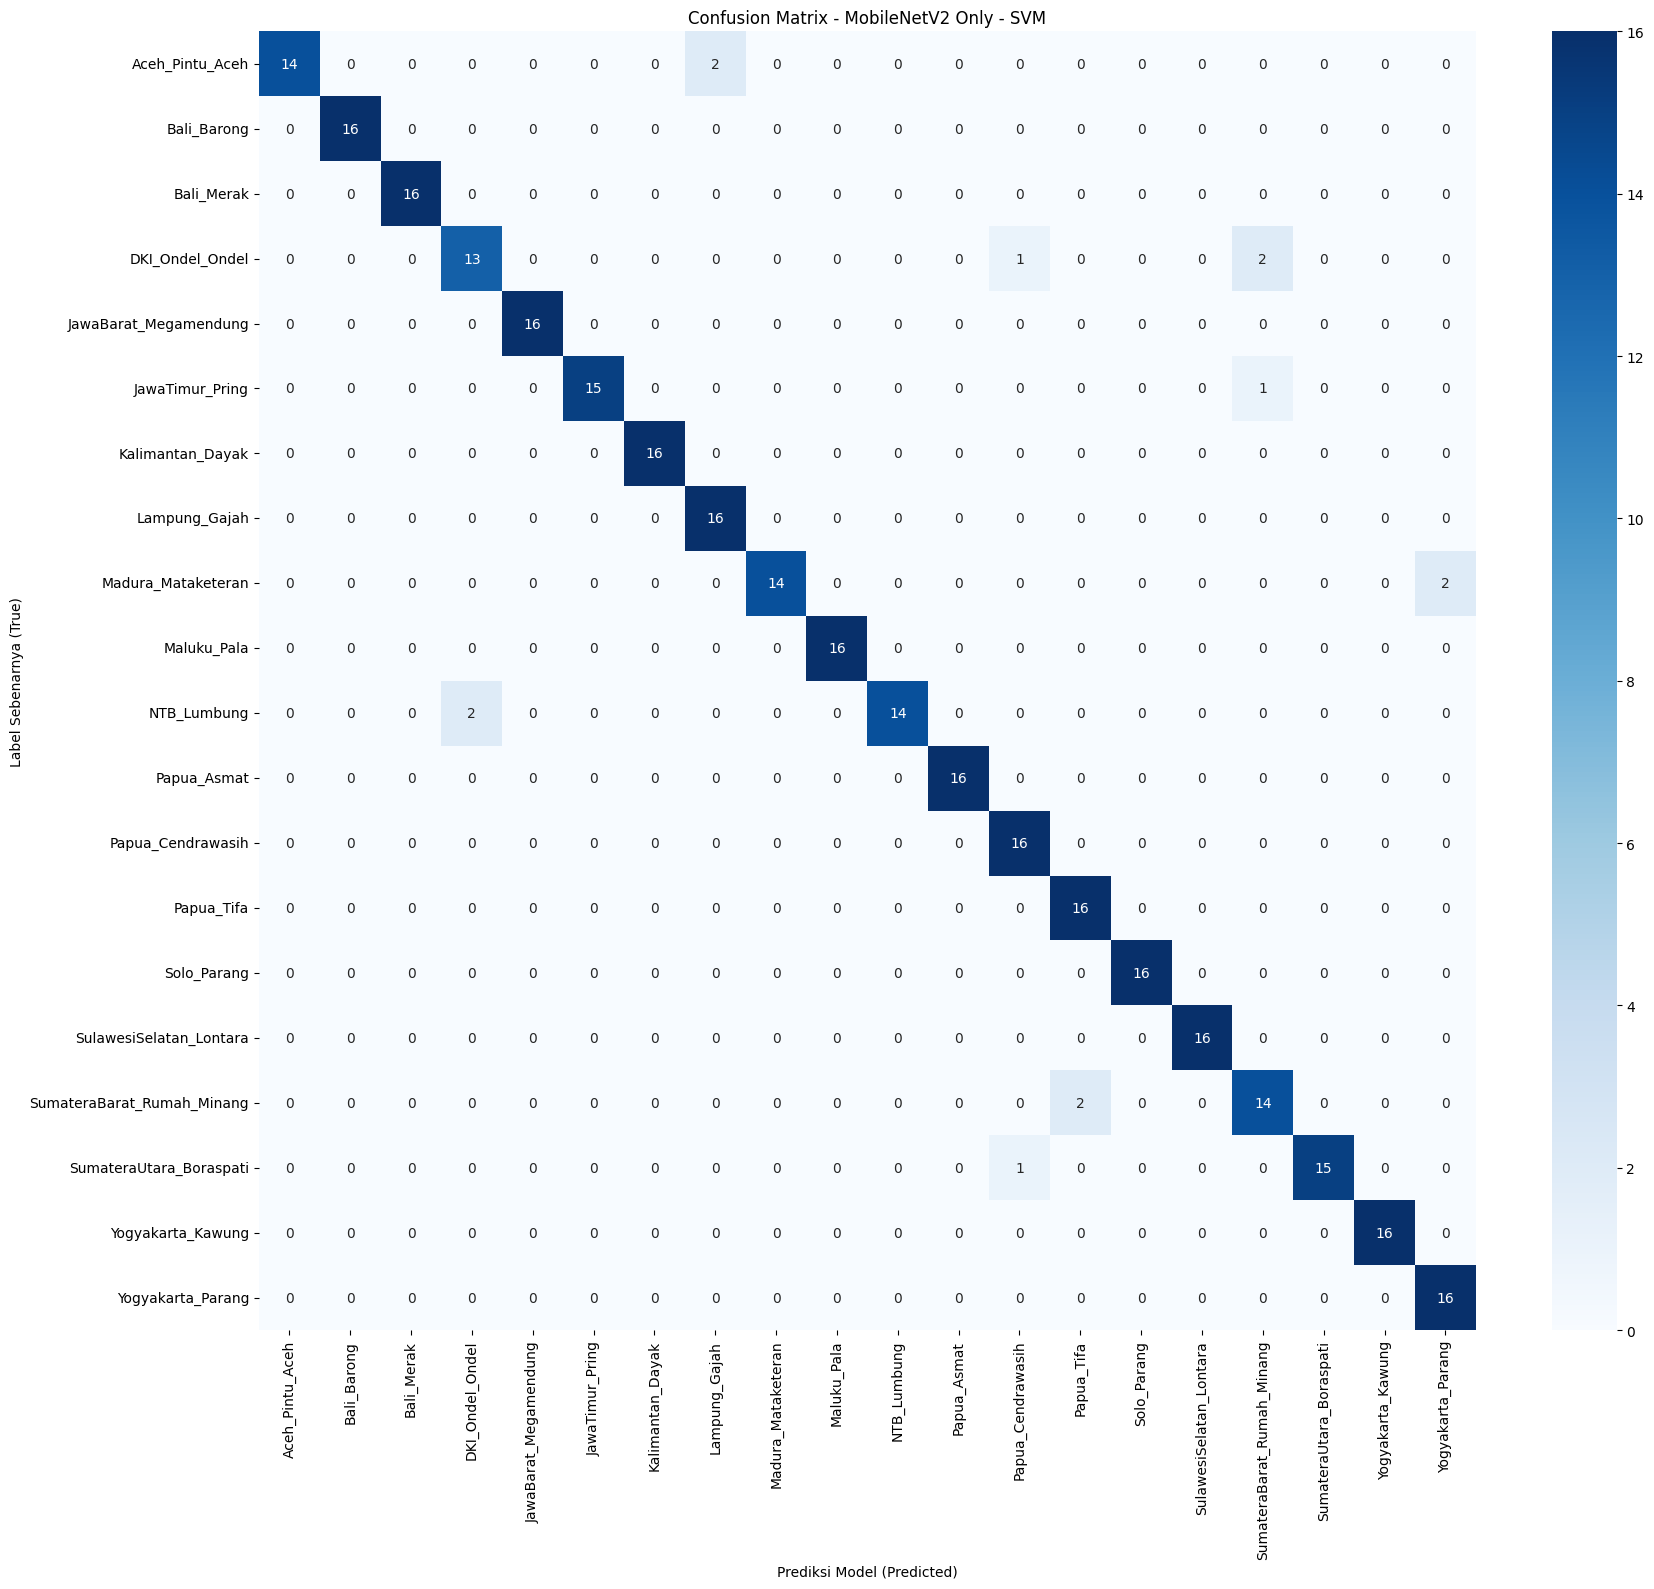


EVALUASI MODEL: K-Nearest Neighbors

--- Classification Report (K-Nearest Neighbors) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.92      0.75      0.83        16
               Bali_Barong       1.00      1.00      1.00        16
                Bali_Merak       1.00      1.00      1.00        16
           DKI_Ondel_Ondel       0.93      0.88      0.90        16
     JawaBarat_Megamendung       1.00      1.00      1.00        16
           JawaTimur_Pring       1.00      0.88      0.93        16
          Kalimantan_Dayak       1.00      1.00      1.00        16
             Lampung_Gajah       0.88      0.94      0.91        16
        Madura_Mataketeran       1.00      0.88      0.93        16
               Maluku_Pala       0.80      1.00      0.89        16
               NTB_Lumbung       1.00      0.88      0.93        16
               Papua_Asmat       0.94      1.00      0.97        16
         Papua_Cendrawasi

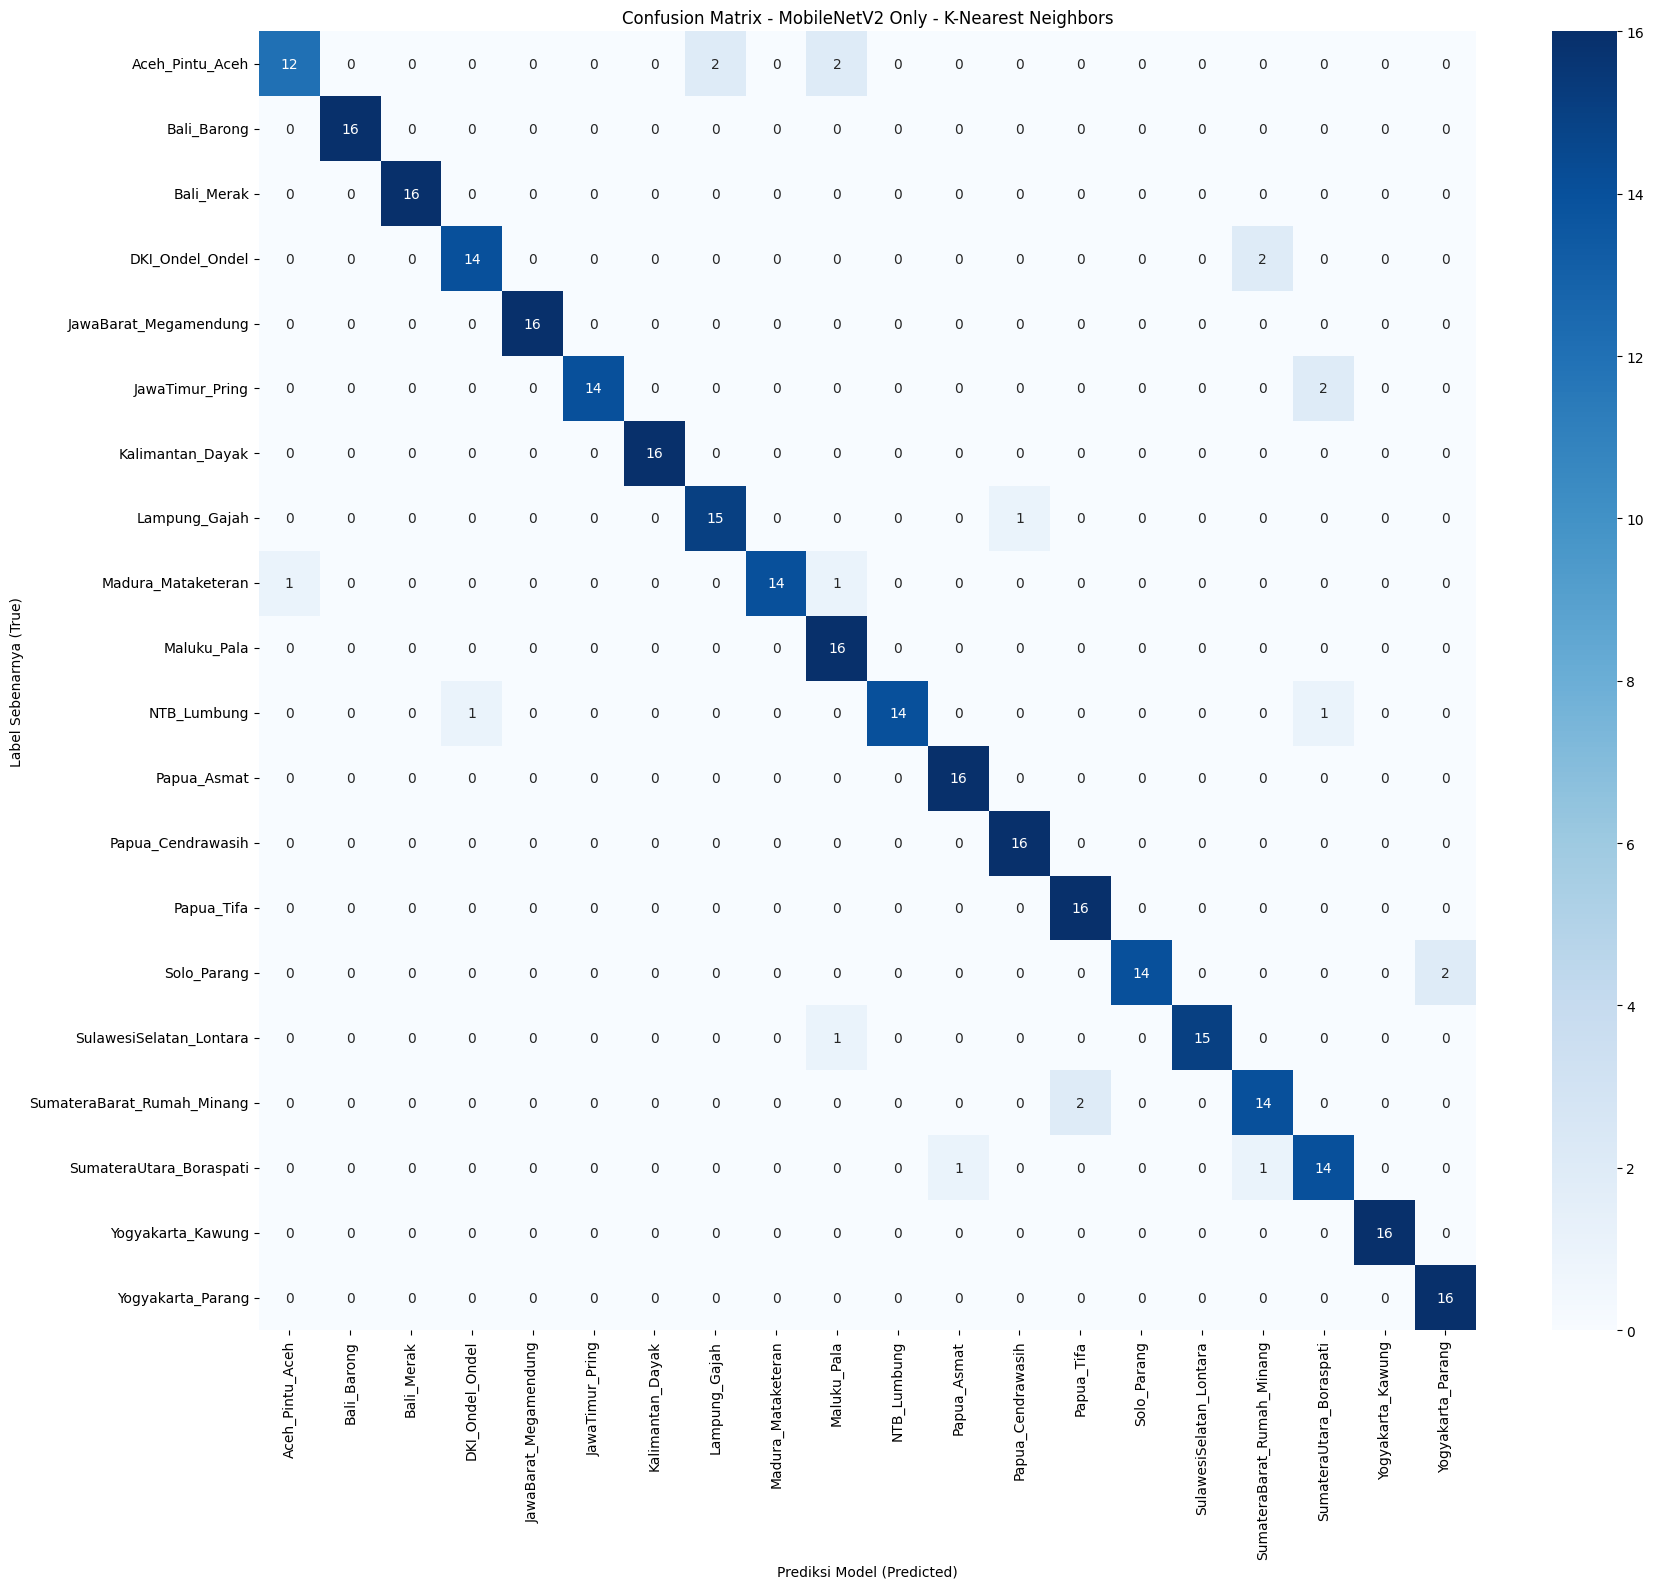


EVALUASI MODEL: Random Forest

--- Classification Report (Random Forest) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.88      0.88      0.88        16
               Bali_Barong       0.89      1.00      0.94        16
                Bali_Merak       1.00      0.88      0.93        16
           DKI_Ondel_Ondel       0.88      0.88      0.88        16
     JawaBarat_Megamendung       0.80      1.00      0.89        16
           JawaTimur_Pring       0.93      0.88      0.90        16
          Kalimantan_Dayak       0.94      1.00      0.97        16
             Lampung_Gajah       0.88      0.94      0.91        16
        Madura_Mataketeran       1.00      0.88      0.93        16
               Maluku_Pala       0.94      0.94      0.94        16
               NTB_Lumbung       0.87      0.81      0.84        16
               Papua_Asmat       0.93      0.88      0.90        16
         Papua_Cendrawasih       1.00

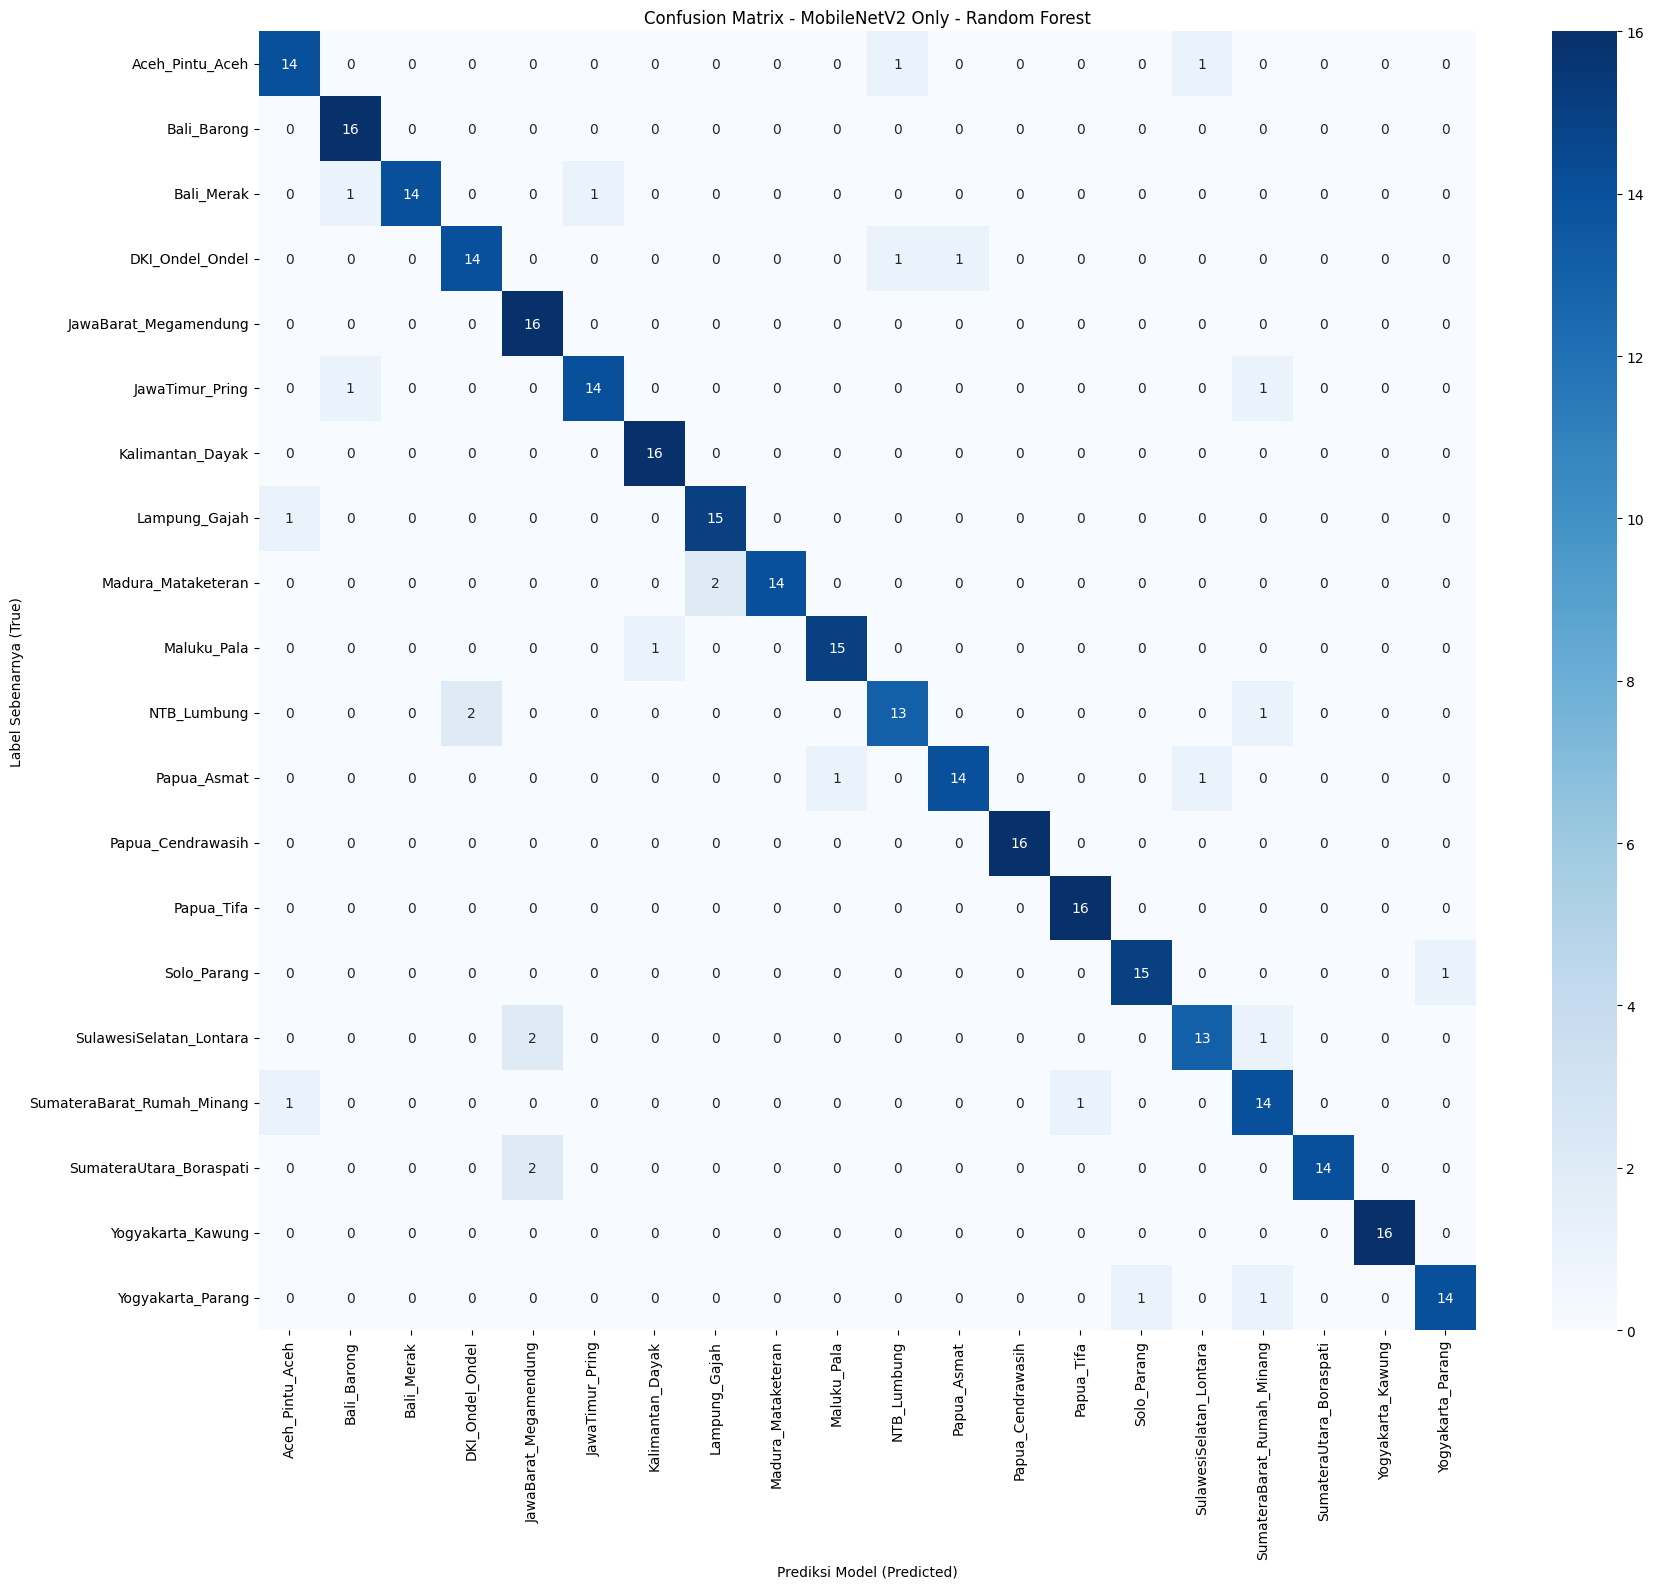


EVALUASI MODEL: Decision Tree

--- Classification Report (Decision Tree) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.57      0.50      0.53        16
               Bali_Barong       0.53      0.56      0.55        16
                Bali_Merak       0.75      0.94      0.83        16
           DKI_Ondel_Ondel       0.50      0.44      0.47        16
     JawaBarat_Megamendung       0.71      0.62      0.67        16
           JawaTimur_Pring       0.47      0.44      0.45        16
          Kalimantan_Dayak       0.83      0.94      0.88        16
             Lampung_Gajah       0.75      0.56      0.64        16
        Madura_Mataketeran       0.91      0.62      0.74        16
               Maluku_Pala       0.50      0.62      0.56        16
               NTB_Lumbung       0.37      0.44      0.40        16
               Papua_Asmat       0.62      0.62      0.62        16
         Papua_Cendrawasih       0.50

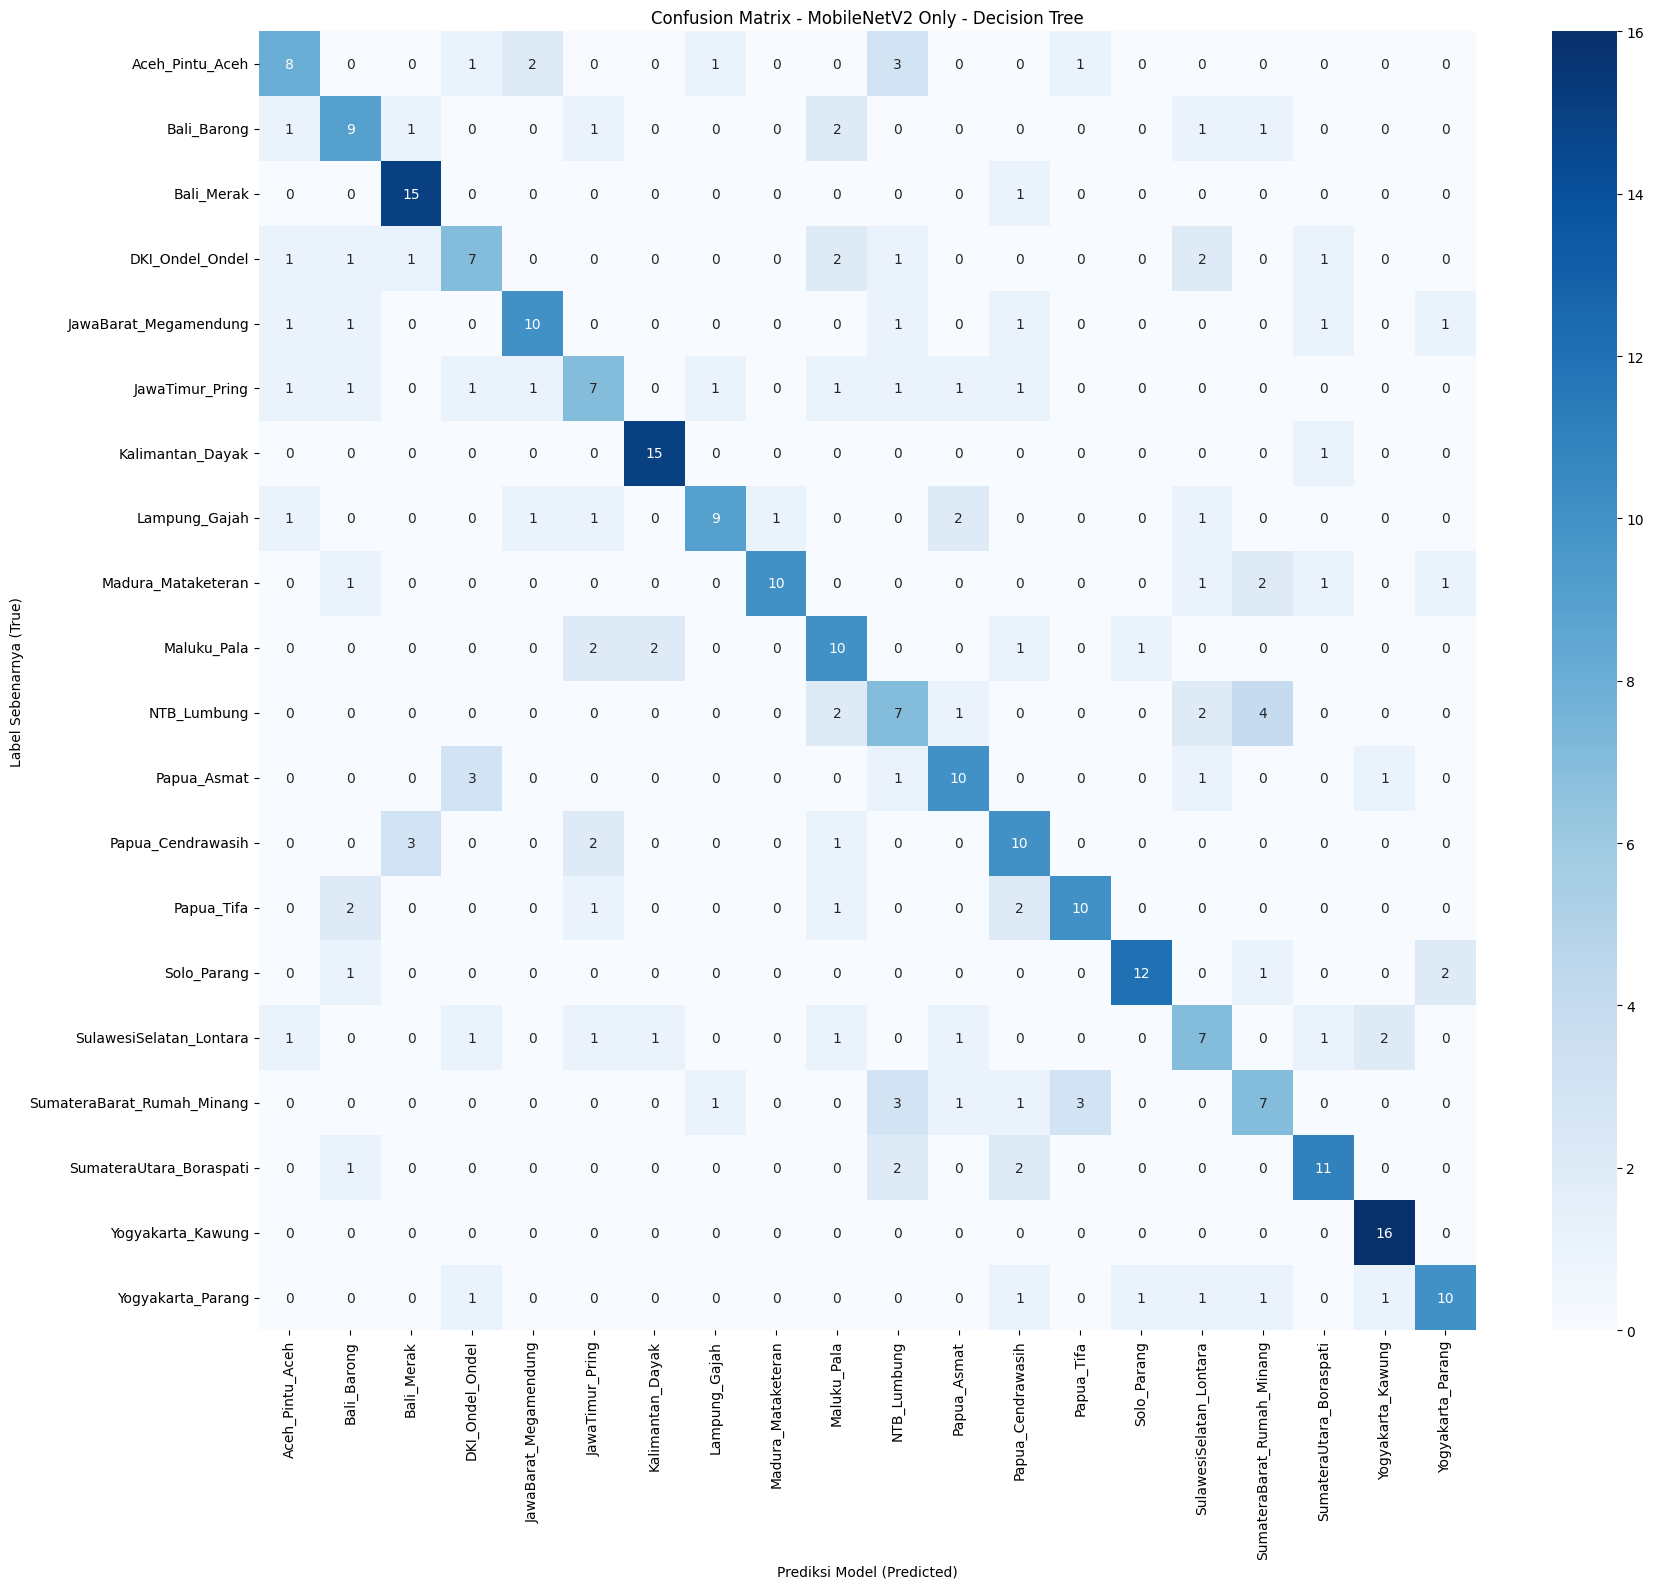


EVALUASI MODEL: Dense Neural Network (MLP)

--- Classification Report (Dense Neural Network (MLP)) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.87      0.81      0.84        16
               Bali_Barong       1.00      1.00      1.00        16
                Bali_Merak       1.00      1.00      1.00        16
           DKI_Ondel_Ondel       1.00      0.75      0.86        16
     JawaBarat_Megamendung       1.00      1.00      1.00        16
           JawaTimur_Pring       0.94      0.94      0.94        16
          Kalimantan_Dayak       1.00      1.00      1.00        16
             Lampung_Gajah       1.00      1.00      1.00        16
        Madura_Mataketeran       1.00      0.88      0.93        16
               Maluku_Pala       1.00      0.88      0.93        16
               NTB_Lumbung       0.80      1.00      0.89        16
               Papua_Asmat       1.00      1.00      1.00        16
         Pa

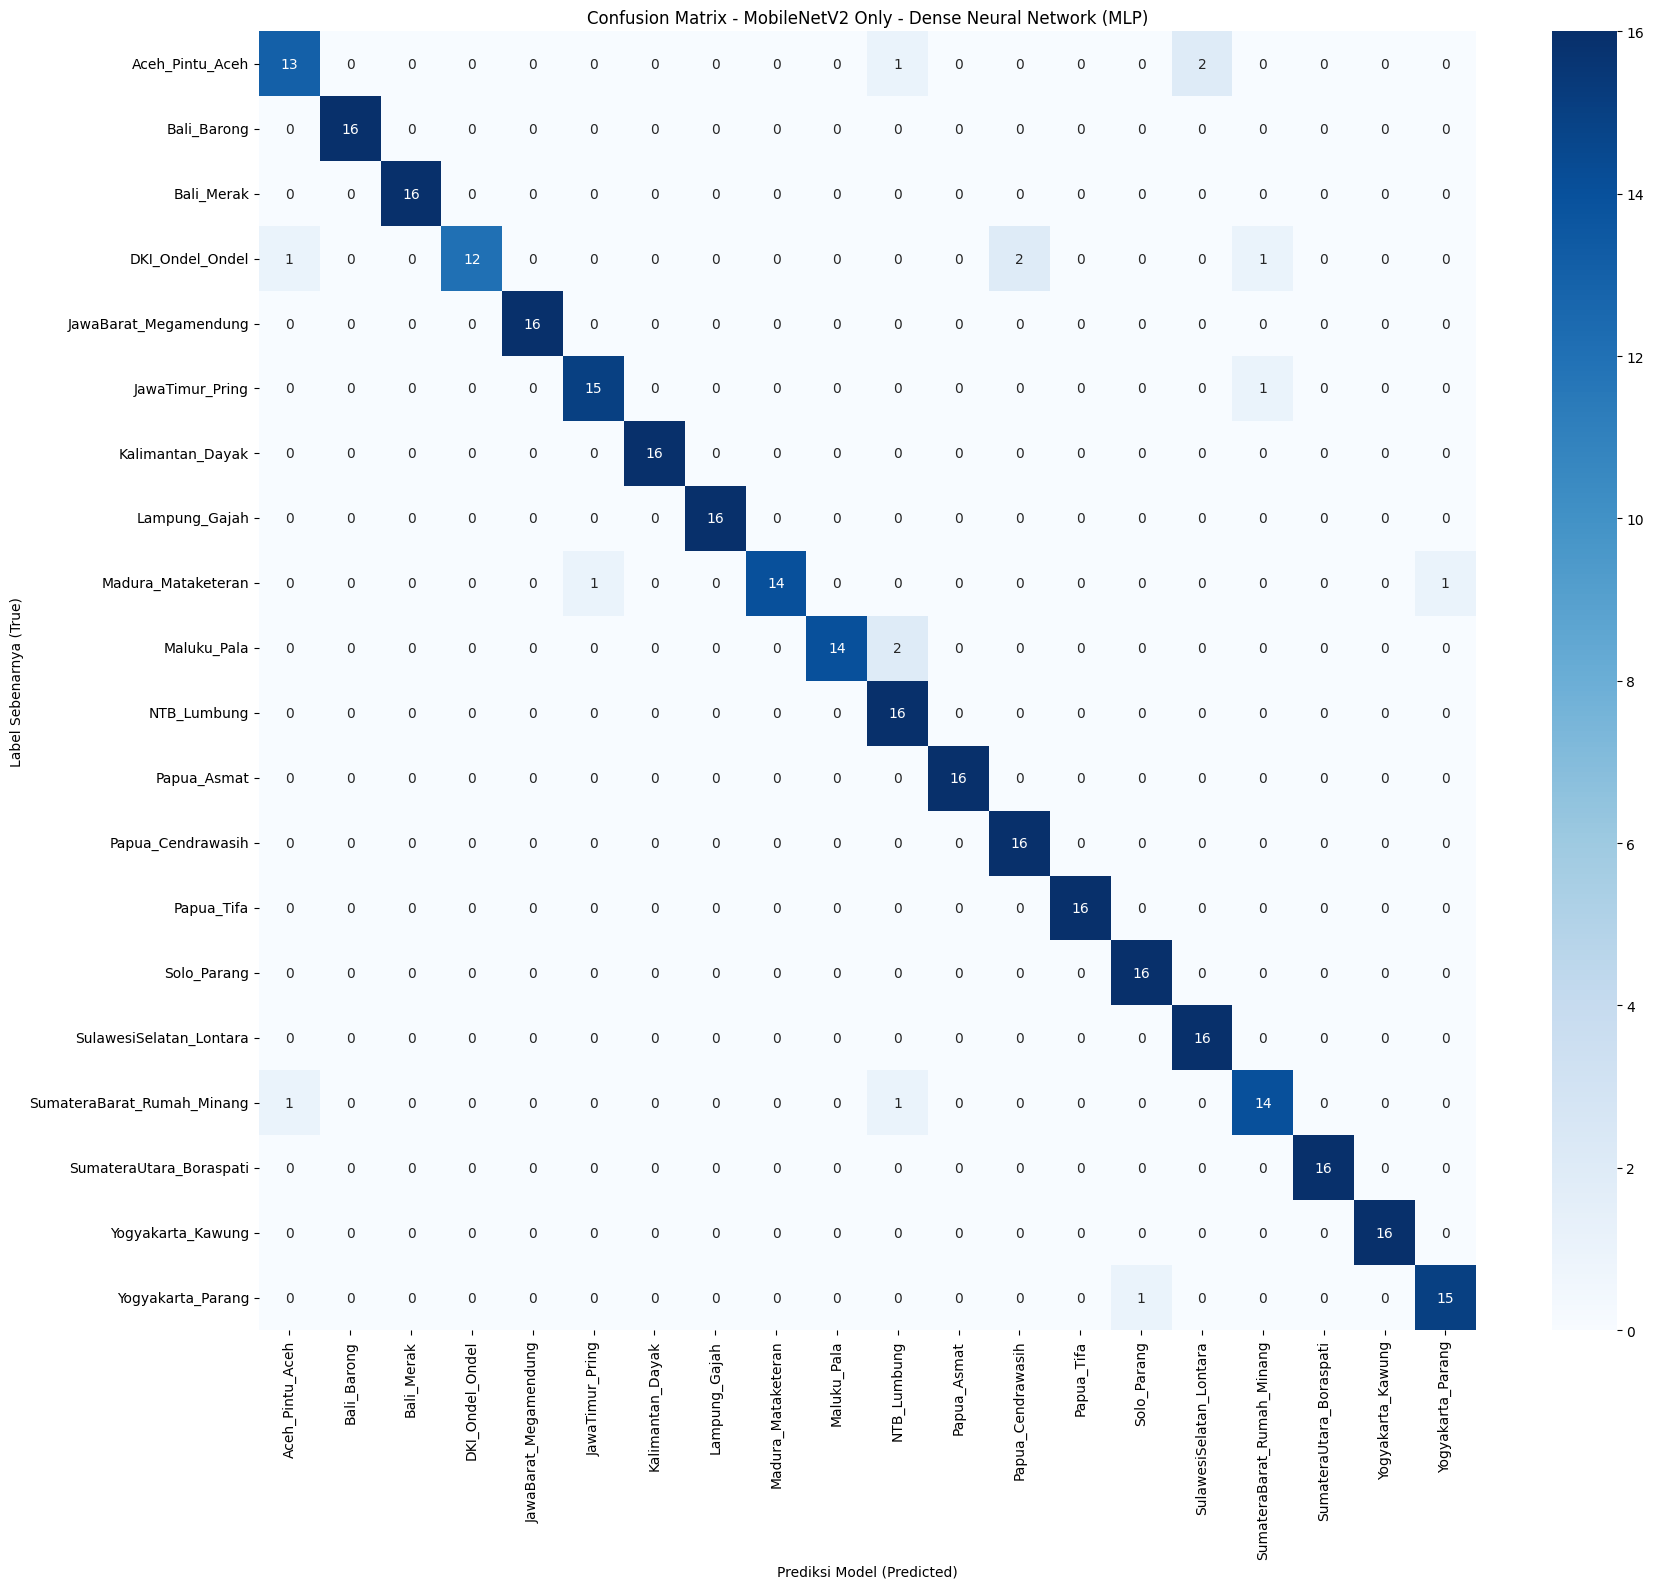

In [6]:
comparison_data = []
for name, res in results.items():
    comparison_data.append({
        "Model": name,
        "Akurasi (%)": round(res['accuracy'] * 100, 2),
        "Waktu Latih (detik)": round(res['train_time'], 4),
        "Waktu Prediksi (detik)": round(res['pred_time'], 4),
        "Parameter Terbaik": res['param_info']
    })

df_compare = pd.DataFrame(comparison_data)
print("=========================================================================================")
print("TABEL PERBANDINGAN MODEL KLASIFIKASI BATIK (MOBILENETV2 SAJA)")
print("=========================================================================================")
display(df_compare)
print("\n")

for name, res in results.items():
    print(f"\n{'='*50}")
    print(f"EVALUASI MODEL: {name}")
    print(f"{'='*50}")
    
    print(f"\n--- Classification Report ({name}) ---")
    print(classification_report(y_test, res['predictions'], target_names=le.classes_))
    
    cm = confusion_matrix(y_test, res['predictions'])
    
    plt.figure(figsize=(18, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - MobileNetV2 Only - {name}')
    plt.ylabel('Label Sebenarnya (True)')
    plt.xlabel('Prediksi Model (Predicted)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
